In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12

In [16]:
df = pd.read_excel('Spectral_library_clean.xlsx')
wavelength = df['Wavelength']
abs_spectra = df.iloc[:, 1:]
abs_spectra = abs_spectra.ffill(axis=0).bfill(axis=0).to_numpy().T

# for spectrum in abs_spectra:
#     plt.plot(wavelength, spectrum)
# plt.show()

In [ ]:
def data_creation(N_training_, N_validation_, noise_level, abs_spectra_):
    # set seed for reproduction purposes
    N_species = len(abs_spectra_)
    N_wavelengths = len(wavelength)
    X = torch.zeros(N_species, (N_training_ + N_validation_), N_wavelengths)
    y = torch.zeros(N_species, (N_training_ + N_validation_), dtype=torch.long) # class needs integer 

    for specie_index, spectra in enumerate(abs_spectra_):
        data = torch.zeros(N_training_ + N_validation_, N_wavelengths)
        for i in range(N_training_ + N_validation_):
            data[i, :] = torch.tensor(spectra, dtype=torch.float32) + noise_level * torch.randn(N_wavelengths)

        X[specie_index] = data
        y[specie_index] = torch.zeros(N_training_ + N_validation_, dtype=torch.long) + int(specie_index)

    # shuffle first
    perm = torch.randperm(X.shape[1])
    X, y = X[:, perm, :], y[:, perm]
    
    # compute stats on training portion only
    mean = X[:, :N_training_, :].mean(dim=(1,2), keepdim=True)
    std  = X[:, :N_training_, :].std(dim=(1,2),  keepdim=True) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets into training and validation
    X_train_, y_train_ = X_norm[:, :N_training_, :], y[:, :N_training_]
    X_val_,   y_val_   = X_norm[:, N_training_:, :], y[:, N_training_:]
    return X_train_, y_train_, X_val_, y_val_

In [193]:
X_train, y_train, X_val, y_val = data_creation(400, 80, .05, abs_spectra)
print(X_train.shape)

torch.Size([9, 400, 451])


In [194]:
def training_loop(nr_epochs, X_train_, y_train_, X_val_, y_val_):
    N_species = len(y_val_)
    model = nn.Sequential(
    nn.Linear(len(wavelength), 64),
    nn.ReLU(),
    nn.Linear(64, N_species)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs   = []
    epochs_list = []

    X_train_ = X_train_.reshape(-1, len(wavelength))        # (9*200, 451) = (1800, 451)
    X_val_ = X_val_.reshape(-1,len(wavelength))
    y_train_ = y_train_.reshape(-1)           # (1800,)
    y_val_ = y_val_.reshape(-1)

    for epoch in range(nr_epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_).squeeze()
        
        # input should be (Ntraining * Nclasses, Nwavelength)
        loss = nn.CrossEntropyLoss()(pred[:, :], y_train_)
        loss.backward()
        optimizer.step()

        # find probability of logit (pred)
        prob = nn.Softmax(dim=1)(pred)
        class_choice = torch.argmax(prob, dim = 1)

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_).squeeze() # same shape as y_val
            loss_val = nn.CrossEntropyLoss()(pred_val[:], y_val_)

            prob_val = nn.Softmax(dim=1)(pred_val)
            class_choice_val = torch.argmax(prob_val, dim = 1)
            
        # if true, we return a 1. Else 0.
        train_acc = (class_choice == y_train_).float().mean().item() * 100
        val_acc = (class_choice_val == y_val_).float().mean().item() * 100

        train_losses.append(loss.item())
        val_losses.append(loss_val.item()) 
        train_accs.append(train_acc)
        val_accs.append(val_acc) 
        epochs_list.append(epoch)
    return train_losses, val_losses, train_accs, val_accs, epochs_list


In [195]:
train_losses, val_losses, train_accs, val_accs, epochs_list = training_loop(400, X_train, y_train, X_val, y_val)

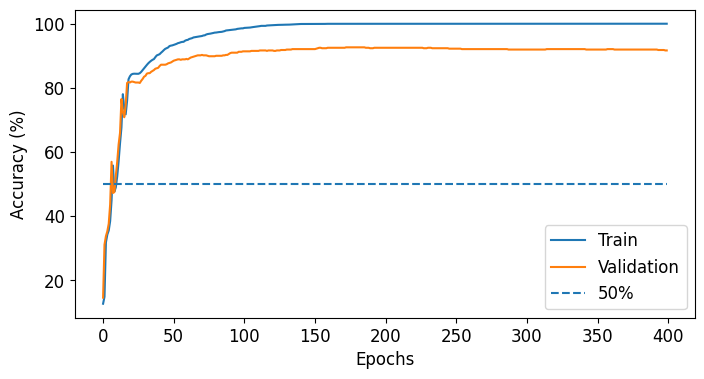

In [196]:
plt.plot(epochs_list, train_accs, label = 'Train')
plt.plot(epochs_list, val_accs, label = 'Validation')
plt.hlines(50, 0, epochs_list[-1], linestyles='--', label = '50%')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

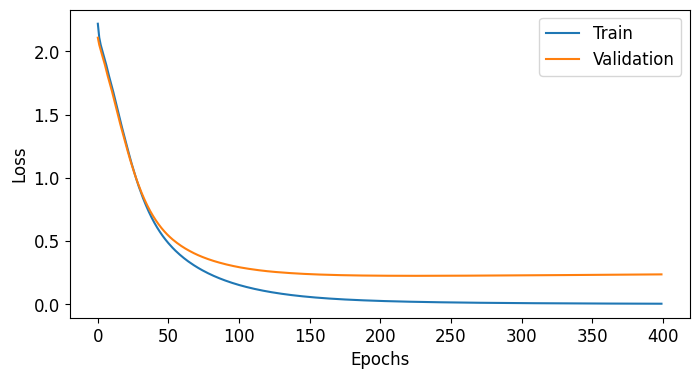

In [197]:
plt.plot(epochs_list, train_losses, label = 'Train')
plt.plot(epochs_list, val_losses, label = 'Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()